<a href="https://colab.research.google.com/github/Bhoomikamalik81/Probation-Project-26/blob/main/bhoomika_task_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Bengaluru_House_Data.csv to Bengaluru_House_Data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

loading data

In [ ]:
df = pd.read_csv("Bengaluru_House_Data.csv")
print("Dataset shape:", df.shape)

Dataset shape: (13320, 9)


In [ ]:
print("First 5 rows:")
print(df.head())

First 5 rows:
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  


In [ ]:
print("Columns:")
print(df.columns.tolist())

Columns:
['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']


In [ ]:
print("Data types:")
print(df.dtypes)

Data types:
area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [ ]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
529


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(12791, 9)


In [ ]:
columns_to_strip = [
    "size",
    "availability",
    "location",
    "society",
    "total_sqft",
    "area_type"
]
for col in columns_to_strip:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

In [ ]:
print("Area type values:")
print(df["area_type"].value_counts())

Area type values:
area_type
Super built-up  Area    8317
Built-up  Area          2398
Plot  Area              1989
Carpet  Area              87
Name: count, dtype: Int64


In [ ]:
print("Availability values:")
print(df["availability"].value_counts())

Availability values:
availability
Ready To Move    10172
18-May             292
18-Dec             284
18-Apr             269
18-Aug             187
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: Int64


In [ ]:
print("Size values:")
print(df["size"].value_counts().head(20))

Size values:
size
2 BHK         4931
3 BHK         4120
4 Bedroom      824
4 BHK          574
3 Bedroom      535
1 BHK          521
2 Bedroom      314
5 Bedroom      291
6 Bedroom      191
1 Bedroom      104
8 Bedroom       84
7 Bedroom       82
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
Name: count, dtype: Int64


In [ ]:
print("Location values:")
print(df["location"].value_counts().head(20))

Location values:
location
Whitefield                  524
Sarjapur  Road              379
Electronic City             289
Kanakpura Road              249
Thanisandra                 232
Yelahanka                   210
Marathahalli                169
Hebbal                      161
Raja Rajeshwari Nagar       159
Uttarahalli                 157
Hennur Road                 149
Bannerghatta Road           149
7th Phase JP Nagar          135
Electronic City Phase II    128
Rajaji Nagar                107
Haralur Road                102
Bellandur                    93
KR Puram                     91
Electronics City Phase 1     88
Hoodi                        88
Name: count, dtype: Int64


In [ ]:
df = df.dropna(subset=["location"]).copy()

In [ ]:
df["room_count"] = pd.to_numeric(df["size"].str.split().str[0], errors="coerce")

In [ ]:
df["property_type"] = df["size"].str.split().str[1]

In [ ]:
print(df["room_count"].isnull().sum())
print(df["property_type"].isnull().sum())
print(df["property_type"].value_counts(dropna=False))

16
16
property_type
BHK        10273
Bedroom     2488
<NA>          16
RK            13
Name: count, dtype: int64


In [ ]:
def convert_sqft(x):
    try:
        x = str(x).strip()
        if "-" in x:
            values = x.split("-")
            low = float(values[0])
            high = float(values[1])
            return (low + high) / 2
        return float(x)
    except:
        return np.nan

In [ ]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft)

In [ ]:
df.dtypes

,0
area_type,string[python]
availability,string[python]
location,string[python]
size,string[python]
society,string[python]
total_sqft,float64
bath,float64
balcony,float64
price,float64
room_count,float64


In [ ]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["room_count"] = pd.to_numeric(df["room_count"], errors="coerce")

In [ ]:
df = df.dropna(subset=["total_sqft", "price", "room_count"])

In [ ]:
print(df["total_sqft"].head())

0    1056.0
1    2600.0
2    1440.0
3    1521.0
4    1200.0
Name: total_sqft, dtype: float64


In [ ]:
df = df[
    (df["total_sqft"] > 0) &
    (df["price"] > 0) &
    (df["room_count"] > 0)
].copy()

In [ ]:
df["society"] = df.groupby("location")["society"].transform(
    lambda x: x.fillna(
        x.mode().iloc[0] if not x.mode().empty else "Unknown"
    )
)

In [ ]:
df["society"] = df["society"].fillna("Unknown")

In [ ]:
print("Missing society:", df["society"].isnull().sum())

Missing society: 0


In [ ]:
if "bath" in df.columns:
    df["bath"] = pd.to_numeric(
        df["bath"],
        errors="coerce"
    )
    df.loc[
        (df["bath"] < 0) | (df["bath"] > 20),
        "bath"
    ] = np.nan
    df["bath"] = df["bath"].fillna(
        df["bath"].median()
    )
else:
    df["bath"] = 0

In [ ]:
print(df["bath"].describe())

count    12728.000000
mean         2.699010
std          1.294223
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         18.000000
Name: bath, dtype: float64


In [ ]:
if "balcony" in df.columns:
    df["balcony"] = pd.to_numeric(
        df["balcony"],
        errors="coerce"
    )
    df.loc[
        (df["balcony"] < 0) | (df["balcony"] > 10),
        "balcony"
    ] = np.nan
    df["balcony"] = df["balcony"].fillna(
        df["balcony"].median()
    )
else:
    df["balcony"] = 0

In [ ]:
print(df["balcony"].describe())

count    12728.000000
mean         1.602766
std          0.807639
min          0.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: balcony, dtype: float64


In [ ]:
df["availability"] = (
    df["availability"]
    .astype("string")
    .str.strip()
)
df["availability"] = df["availability"].replace("",pd.NA)
df["availability"] = df["availability"].fillna("Unknown")

In [ ]:
df["availability"] = df["availability"].apply(
    lambda x:
        "Ready To Move"
        if x in ["Ready To Move", "Immediate Possession"]
        else "Future"
        if x != "Unknown"
        else "Unknown"
)

In [ ]:
print(df["availability"].value_counts())

availability
Ready To Move    10132
Future            2596
Name: count, dtype: int64


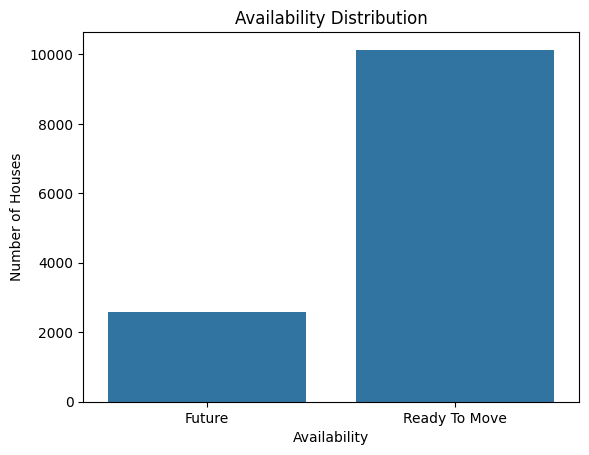

In [ ]:
sns.countplot(data=df,x="availability")
plt.title("Availability Distribution")
plt.xlabel("Availability")
plt.ylabel("Number of Houses")
plt.show()

In [ ]:
df["price_per_sqft"] = (df["price"] * 100000)/df["total_sqft"]

In [ ]:
df["sqft_per_room"] = (df["total_sqft"]/df["room_count"])

removing suspicious data

In [ ]:
df = df[(df["sqft_per_room"] >= 300) &(df["room_count"] <= 10) &(df["bath"] <= df["room_count"] + 2)].copy()

In [ ]:
print("Shape after filtering:", df.shape)

Shape after filtering: (11981, 13)


In [ ]:
print(df.columns.tolist())

['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price', 'room_count', 'property_type', 'price_per_sqft', 'sqft_per_room']


In [ ]:
print("\nUnknown Society Count:")
print((df["society"] == "Unknown").sum())
print("\nFinal Dataset Shape:", df.shape)


Unknown Society Count:
1134

Final Dataset Shape: (11981, 13)


logistic regression

In [ ]:
df["target"] = df["availability"].map({"Ready To Move": 1,"Future": 0})

In [ ]:
print(df[["availability", "target"]].head(10))

     availability  target
0          Future       0
1   Ready To Move       1
2   Ready To Move       1
3   Ready To Move       1
4   Ready To Move       1
5   Ready To Move       1
6          Future       0
7   Ready To Move       1
8   Ready To Move       1
10         Future       0


In [ ]:
features = ["total_sqft","room_count","bath","balcony","price","price_per_sqft","sqft_per_room","location","society","area_type"]

In [ ]:
X = df[features].copy()
y = df["target"].copy()

In [ ]:
categorical = ["location","society","area_type"]

one hot encoding

In [ ]:
X = pd.get_dummies(X,columns=categorical,drop_first=True)

In [ ]:
print("X shape:", X.shape)

X shape: (11981, 3870)


In [ ]:
X = X.astype(int)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20,random_state=42,stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8661


In [ ]:
precision = precision_score(y_test,y_pred)
print("Precision:", round(precision, 4))

Precision: 0.8961


In [ ]:
recall = recall_score(y_test,y_pred)
print("Recall:", round(recall, 4))

Recall: 0.9384


In [ ]:
f1 = f1_score(y_test,y_pred)
print("F1 Score:", round(f1, 4))

F1 Score: 0.9168


In [ ]:
print(classification_report(y_test,y_pred,target_names=["Future","Ready To Move"]))

               precision    recall  f1-score   support

       Future       0.73      0.60      0.66       513
Ready To Move       0.90      0.94      0.92      1884

     accuracy                           0.87      2397
    macro avg       0.81      0.77      0.79      2397
 weighted avg       0.86      0.87      0.86      2397



In [ ]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 308  205]
 [ 116 1768]]


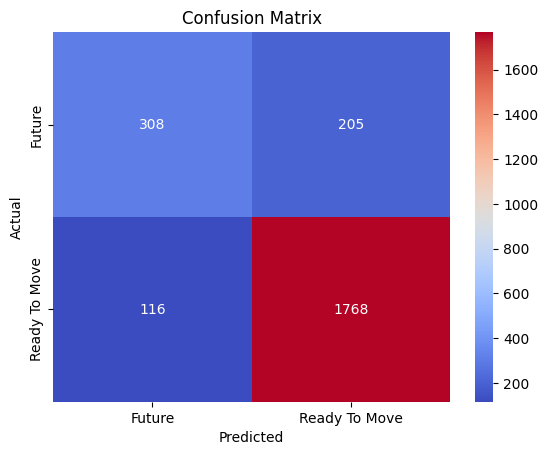

In [ ]:
sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Future", "Ready To Move"],yticklabels=["Future", "Ready To Move"],cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
comparison = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})
print(comparison.head(20))

       Actual  Predicted
7425        1          1
9324        1          1
10347       1          1
11486       1          1
11373       1          1
9647        1          1
6806        1          1
10418       1          1
3624        0          1
2930        1          1
12529       1          1
1336        1          1
61          1          1
1966        0          0
1308        0          1
2994        1          1
8223        1          1
11598       1          1
9539        0          1
893         1          1


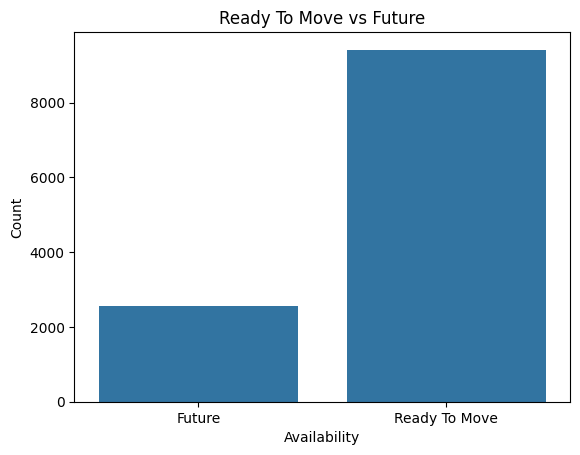

In [ ]:
sns.countplot(data=df,x="availability")
plt.title("Ready To Move vs Future")
plt.xlabel("Availability")
plt.ylabel("Count")
plt.show()

In [ ]:
print("LOGISTIC REGRESSION RESULTS")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

LOGISTIC REGRESSION RESULTS
---------------------------
Accuracy : 0.8661
Precision: 0.8961
Recall   : 0.9384
F1 Score : 0.9168


### Conclusion

The Logistic Regression model performed well in predicting the availability status of properties. The model achieved an **accuracy of 86.61%**, meaning that it correctly classified approximately 87 out of 100 properties. The **precision of 89.61%** and **recall of 93.84%** show that the model was particularly effective in identifying Ready To Move properties. The **F1 Score of 91.68%** also indicates a good balance between precision and recall.

Overall, the model provides a **good classification performance** for predicting whether a property is Ready To Move or Future based on the selected features.
